<a target="_blank" href="https://colab.research.google.com/github/seap-udea/fargopy/blob/main/REFACTORING.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<p align="left"><img src="https://github.com/seap-udea/fargopy/raw/refactor/docs/fargopy_logo.webp" width="300" /></p>

# FARGOpy refactoring: a guide for early adoption users

Sometimes, due to usage or after training activities, FARGOpy developers make modifications to the package that can cause code developed in the past to stop working or require adjustments for new versions of **FARGOpy**. In this notebook, we show which code may change with version updates and how to adapt to continue obtaining the same results.

## Before starting

In [76]:
try:
    from google.colab import drive
    %pip install -Uq git+https://github.com/seap-udea/fargopy
except ImportError:
    print("Not running in Colab, skipping installation")
    %load_ext autoreload
    %autoreload 2

import fargopy as fp

Not running in Colab, skipping installation
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
simpath = fp.Simulation.download_precomputed('fargo')
sim = fp.Simulation(output_dir=simpath)

Precomputed output directory '/tmp/fargo' already exist
Your simulation is now connected with '/Users/jzuluaga/fargo3d/'
Now you are connected with output directory '/tmp/fargo'
Found a variables.par file in '/tmp/fargo', loading properties
Loading variables
84 variables loaded
Simulation in 2 dimensions
Loading domain in cylindrical coordinates:
	Variable phi: 384 [[0, np.float64(-3.1334114227210694)], [-1, np.float64(3.1334114227210694)]]
	Variable r: 128 [[0, np.float64(0.408203125)], [-1, np.float64(2.491796875)]]
	Variable z: 1 [[0, np.float64(0.0)], [-1, np.float64(0.0)]]
Number of snapshots in output directory: 51
Planets found in summary.dat
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


## Introducing versions 1.1.X

In **February 10 2026** we introduce major changes in **FARGOpy**, especially in the way as the fields are managed. Those changes are intended for regularizing the way as the package is used, both in the raw-data mode and the interpolation mode.

### Reading fields

In previous versions you load a field using:

```python
gasdens = sim.load_field('gasdens', snapshot=20, interpolate=False)
```

In these versions and ahead:

- We drop the option `interpolate` 
- You need to force the slice from the reading of the data.

In the new versions and ahead:

In [78]:
gasdens = sim.load_field('gasdens', snapshot=20, slice='z=0')

### Mesh slices

In previous versions you slice the field *after* loading it:

```python
gasdens_plane, mesh = gasdens.meshslice(slice='z=0')
```

In the new version the fields are already sliced. On the other hand, the `gasdens` object is an object of the type `FieldInterpolator` and the access to the data (`gasdens_plane`) and the meshgrid (`mesh`) are available in different variables.

**Minimal solution**: If you don't want to modify significantly your codem you may change the previous command with:

In [79]:
raw_data = sim.field_handler.get_raw_data()
gasdens_plane, mesh = raw_data.data, raw_data.mesh

**Adapted to new version**: In the new version the best practice solution to obtain the previous behaviour will be:

In [84]:
import numpy as np
gasdens_plane = np.array(gasdens.gasdens_mesh[0])
mesh = fp.Dictobj(
    x=np.array(gasdens.var1_mesh[0]), 
    y=np.array(gasdens.var2_mesh[0])
)

And now you can plot it using **deprecated styles**:

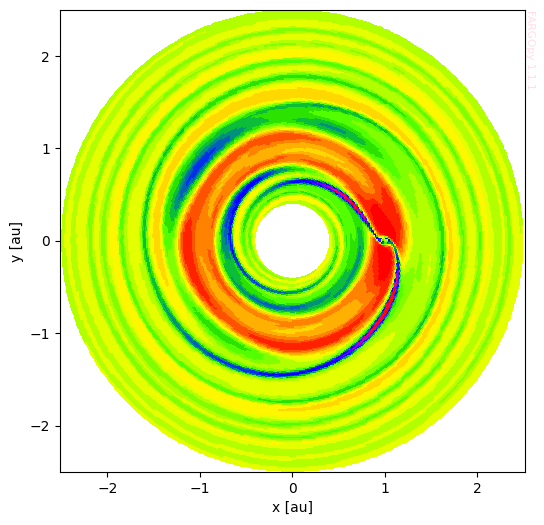

In [85]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,6))
ax.pcolormesh(mesh.x, mesh.y, gasdens_plane, cmap='prism')
ax.axis('equal')
ax.set_xlabel('x [au]')
ax.set_ylabel('y [au]')
mark = fp.Plot.fargopy_mark(ax)

**Best practice**: In the new version the previous behaviour can be obtained using the following code:

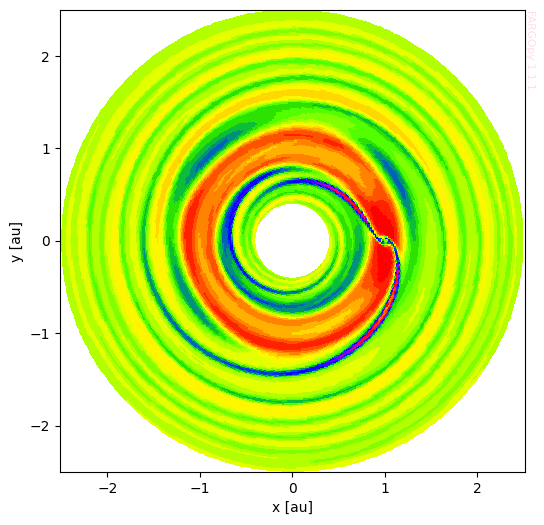

In [ ]:
fields_cartesian = sim.load_field(
    fields='gasdens',
    snapshot=[1, sim.nsnaps-1],
    coords='cartesian',
    slice='z=0'
)

snapshot = 20
gasdens_plane = fields_cartesian.gasdens_mesh[snapshot]
x = fields_cartesian.var1_mesh[snapshot]
y = fields_cartesian.var2_mesh[snapshot]

fig, ax = plt.subplots(figsize=(6,6))
ax.pcolormesh(x, y, gasdens_plane, cmap='prism')
ax.axis('equal')
ax.set_xlabel('x [au]')
ax.set_ylabel('y [au]')
mark = fp.Plot.fargopy_mark(ax)


### Reading all fields

In previous versions you can load with a single command all fields:

```python
gasdens_all = sim.load_allfields('gasdens')
```

In these versions and ahead fields should be read indicating them explicitely:

In [73]:
gasdens_all = sim.load_field(['gasdens','gasv'], snapshot=[0, sim.nsnaps-1], slice='z=0')

### Automatic conversion to cartesian coordinates

In previous versions when you read a field, you automatically get an object (mesh) having the cartesian coordinates:

```python
gasdens_all = sim.load_allfields('gasdens')
gasdens_snap = gasdens_all[20].gasdens
gasdens_plane,mesh = gasdens_snap.meshslice(slice='z=0')
```

**Minimal solution**:

In [74]:
gasdens_all = sim.load_field('gasdens', snapshot=20, slice='z=0')
raw_data = sim.field_handler.get_raw_data()
gasdens_plane, mesh = raw_data.data, raw_data.mesh

**Adapted to new version**:

In the new version, if you want to plot simultaneously information in cartesian and cyllindrical coordinates, you need to obtain the fileds in both coordinate systems independently:

In [87]:
fields_cyl = sim.load_field(
    fields='gasdens',
    snapshot=[1, sim.nsnaps-1],
    coords='cyllindrical',
    slice='z=0'
)

fields_cartesian = sim.load_field(
    fields='gasdens',
    snapshot=[1, sim.nsnaps-1],
    coords='cartesian',
    slice='z=0'
)

gasdens_plane = np.array(fields_cartesian.gasdens_mesh[20])
mesh = fp.Dictobj(
    x=np.array(fields_cartesian.var1_mesh[20]), 
    y=np.array(fields_cartesian.var2_mesh[20]),
    phi=np.array(fields_cyl.var1_mesh[20]),
    r=np.array(fields_cyl.var2_mesh[20])
)

And now you can plot it using **deprecated styles**:

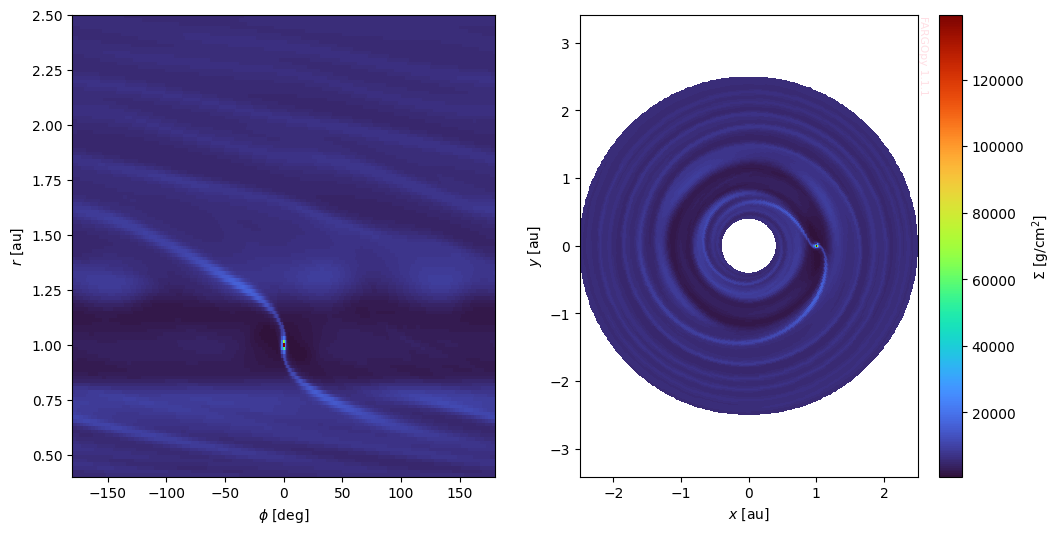

In [88]:
fig,axs = plt.subplots(1,2,figsize=(12,6))
cmap = 'turbo'

ax = axs[0]
ax.pcolormesh(mesh.phi*fp.RAD,mesh.r*sim.UL/fp.AU,gasdens_plane*sim.USIGMA,cmap=cmap)
ax.set_xlabel('$\phi$ [deg]')
ax.set_ylabel('$r$ [au]')

ax = axs[1]
c = ax.pcolormesh(mesh.x*sim.UL/fp.AU,mesh.y*sim.UL/fp.AU,gasdens_plane*sim.USIGMA,cmap=cmap)
ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$y$ [au]')
ax.axis('equal')
fp.Plot.fargopy_mark(ax)

axc = fig.colorbar(c)
axc.set_label("$\Sigma$ [g/cm$^2$]")
plt.savefig('gallery/fargopy-tutorial-animations_0.png') # Save figure

**Best practice**: In the new version the previous behaviour can be obtained using the following code:

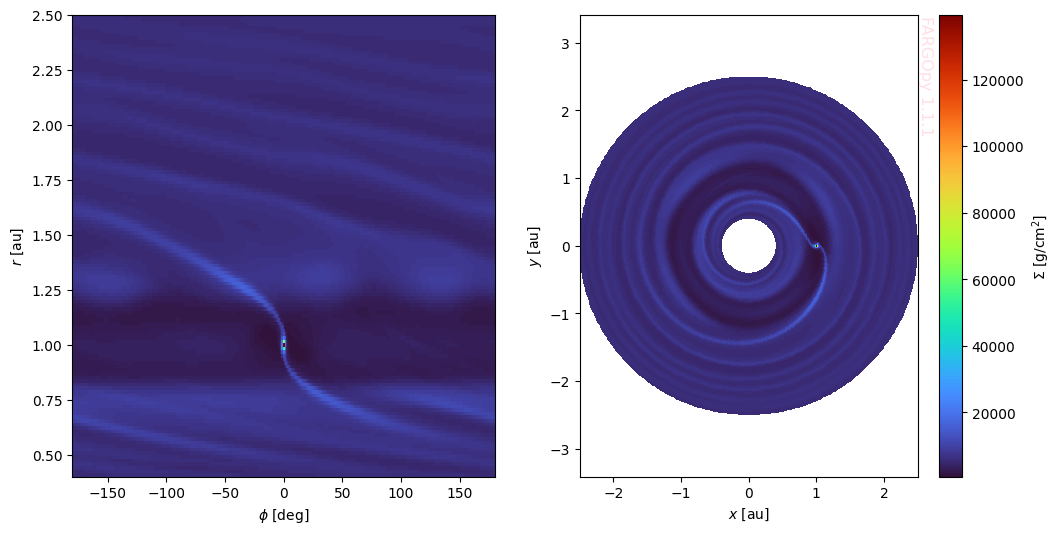

In [91]:
fields_cyl = sim.load_field(
    fields='gasdens',
    snapshot=[1, sim.nsnaps-1],
    coords='cyllindrical',
    slice='z=0'
)

fields_cartesian = sim.load_field(
    fields='gasdens',
    snapshot=[1, sim.nsnaps-1],
    coords='cartesian',
    slice='z=0'
)

snapshot = 20

phi = fields_cyl.var1_mesh[snapshot]
r = fields_cyl.var2_mesh[snapshot]

x = fields_cartesian.var1_mesh[snapshot]
y = fields_cartesian.var2_mesh[snapshot]
gasdens_plane = fields_cartesian.gasdens_mesh[snapshot]

plt.close('all')
fig,axs = plt.subplots(1,2,figsize=(12,6))
cmap = 'turbo'

ax = axs[0]
ax.pcolormesh(phi*fp.RAD,r*sim.UL/fp.AU,gasdens_plane*sim.USIGMA,cmap=cmap)
ax.set_xlabel('$\phi$ [deg]')
ax.set_ylabel('$r$ [au]')

ax = axs[1]
c = ax.pcolormesh(x*sim.UL/fp.AU,y*sim.UL/fp.AU,gasdens_plane*sim.USIGMA,cmap=cmap)
ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$y$ [au]')
ax.axis('equal')
fp.Plot.fargopy_mark(ax, frac=1/4)

axc = fig.colorbar(c)
axc.set_label("$\Sigma$ [g/cm$^2$]")
plt.savefig('gallery/fargopy-tutorial-animations_0.png') # Save figure

---
*Powered by fargopy*. For more examples see [fargopy GitHub repo](https://github.com/seap-udea/fargopy/tree/main/examples). 

Jorge I. Zuluaga, Alejandro Murillo-González and Matías Montesinos © 2023-present
